Data shape: (200352, 275)
Explained variance ratio: [0.31465965 0.1405366 ]


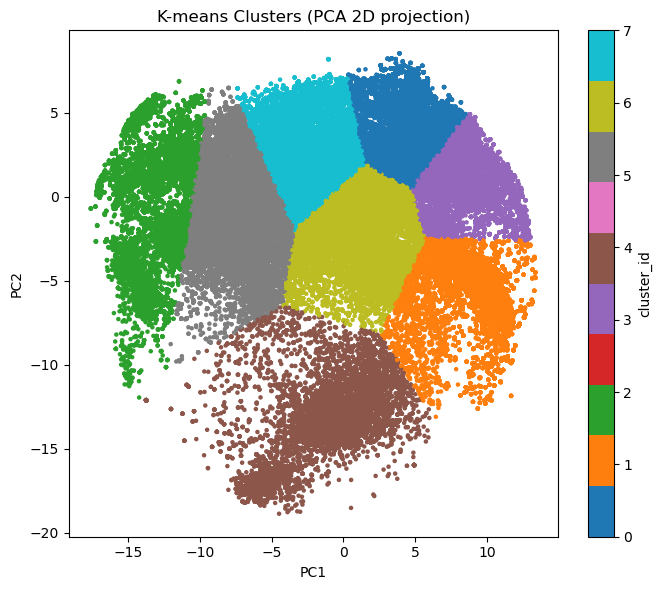

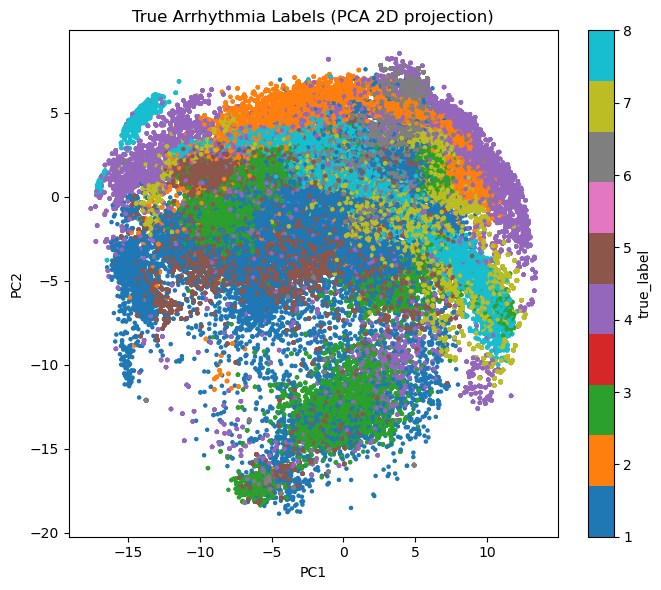

In [2]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

df = pd.read_csv("train_patients.csv", header=None)
X = df.iloc[:, :275].values
y = df.iloc[:, 275].values

print("Data shape:", X.shape)

# PCA降到2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

print("Explained variance ratio:", pca.explained_variance_ratio_)

# K-means聚类
kmeans = KMeans(n_clusters=8, random_state=42)
cluster_labels = kmeans.fit_predict(X_pca)

# 可视化
plt.figure(figsize=(7,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=cluster_labels, cmap="tab10", s=5)
plt.title("K-means Clusters (PCA 2D projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="cluster_id")
plt.tight_layout()
plt.show()

# 真实标签对比
plt.figure(figsize=(7,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap="tab10", s=5)
plt.title("True Arrhythmia Labels (PCA 2D projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="true_label")
plt.tight_layout()
plt.show()

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

X_cluster = cluster_labels.reshape(-1, 1)
y_true = y

X_tr, X_te, y_tr, y_te = train_test_split(X_cluster, y_true, test_size=0.25, random_state=42)

clf = LogisticRegression(max_iter=200)
clf.fit(X_tr, y_tr)
pred = clf.predict(X_te)

print("Classification accuracy based on cluster labels:", accuracy_score(y_te, pred))

Classification accuracy based on cluster labels: 0.2038013096949369


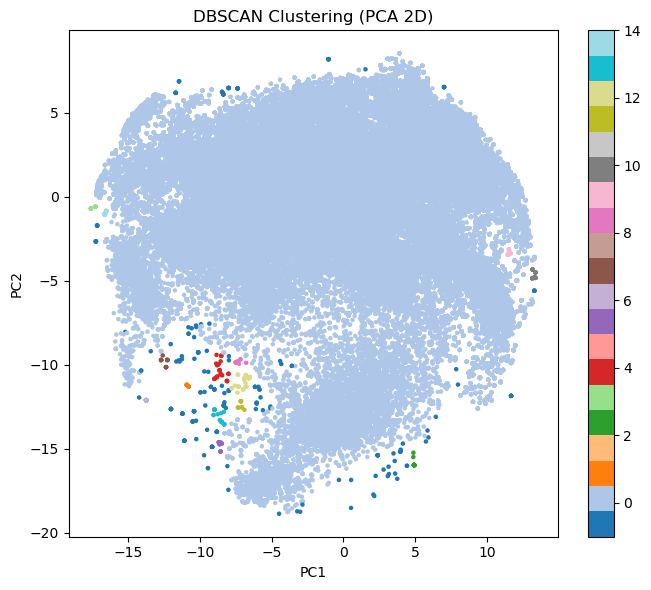

Number of clusters found: 16
Noise points: 208


In [5]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.5, min_samples=10)
cluster_db = db.fit_predict(X_pca)

plt.figure(figsize=(7,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=cluster_db, cmap="tab20", s=5)
plt.title("DBSCAN Clustering (PCA 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar()
plt.tight_layout()
plt.show()

print("Number of clusters found:", len(set(cluster_db)))
print("Noise points:", sum(cluster_db == -1))


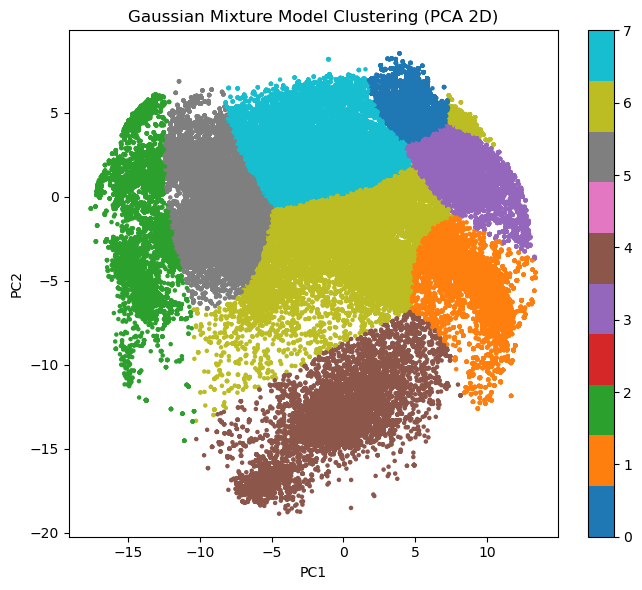

In [6]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=8, covariance_type="full", random_state=42)
gmm.fit(X_pca)
cluster_gmm = gmm.predict(X_pca)

plt.figure(figsize=(7,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=cluster_gmm, cmap="tab10", s=5)
plt.title("Gaussian Mixture Model Clustering (PCA 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar()
plt.tight_layout()
plt.show()


Subset shape: (5000, 2)


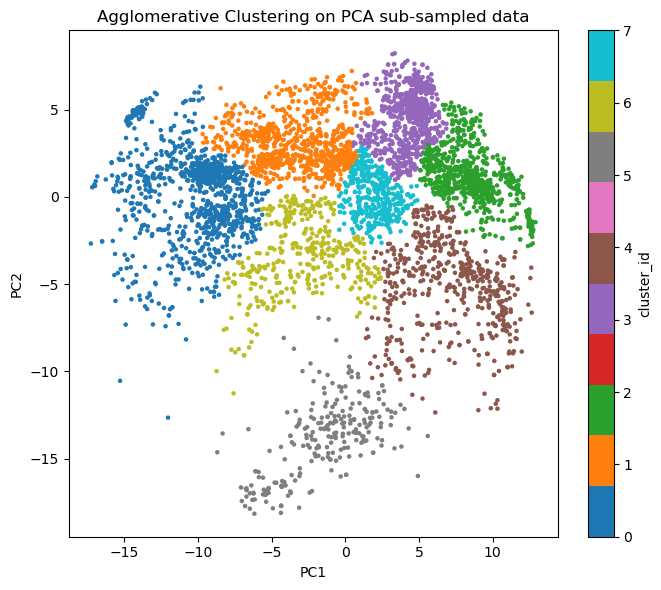

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

SUBSET_SIZE = 5000

# 分层抽样
X_sub, _, y_sub, _ = train_test_split(
    X_pca, y,
    train_size=SUBSET_SIZE,
    stratify=y,
    random_state=42
)

print("Subset shape:", X_sub.shape)

# 子集上做Agglomerative
agg = AgglomerativeClustering(n_clusters=8, linkage="ward")
cluster_agg = agg.fit_predict(X_sub)

plt.figure(figsize=(7, 6))
plt.scatter(X_sub[:, 0], X_sub[:, 1], c=cluster_agg, cmap="tab10", s=5)
plt.title("Agglomerative Clustering on PCA sub-sampled data")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="cluster_id")
plt.tight_layout()
plt.show()

c:\Users\AlexCheng\.conda\envs\idss\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=20.
  warnings.warn(


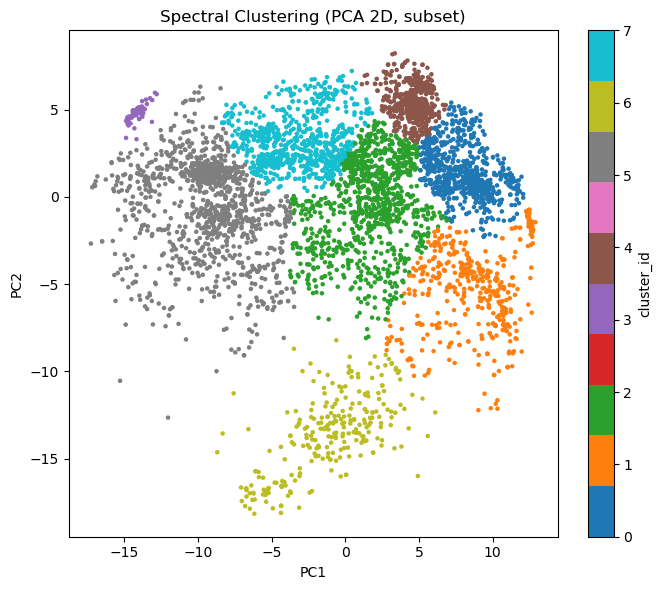

In [9]:
from sklearn.cluster import SpectralClustering
import matplotlib.pyplot as plt

spectral = SpectralClustering(
    n_clusters=8,
    affinity="nearest_neighbors",
    n_neighbors=15,
    assign_labels="kmeans",
    random_state=42,
    n_init=10
)

cluster_spec = spectral.fit_predict(X_sub)

plt.figure(figsize=(7, 6))
plt.scatter(X_sub[:, 0], X_sub[:, 1], c=cluster_spec, cmap="tab10", s=5)
plt.title("Spectral Clustering (PCA 2D, subset)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="cluster_id")
plt.tight_layout()
plt.show()
